In [28]:
import pandas as pd
import numpy as np
import sys
sys.path.insert(0,"../")
from data import get_data, get_site_ids, aggregate_by_interval


_VIOLATION_AMOUNT = 10 # in mg/L
_WINDOW_LENGTH = "7D"

In [20]:
def stats(site_uid, window_length = _WINDOW_LENGTH, violation_amt = _VIOLATION_AMOUNT):
    w = get_data(site_uid=site_uid).water
    start, end = w.index.min(), w.index.max()
    life = (end - start).total_seconds()/(365.25 * 3600 * 24)
    rate = w[w.nitrate_con >= violation_amt].shape[0]/w.shape[0]
    s = w['nitrate_con'].dropna()
    wk = s.resample(window_length).max()
    n = wk.notna().sum()
    return life, rate*100, n

print(f"{str("Site"):<22} {str("Lifetime (yr)"):<20} {str("Rate"):<15} {str("7-Day Windows w Data"):<20}")
for site in get_site_ids():
    print("{:<22} {:<20.2f} {:<15.1f} {:<20}".format(site, *stats(site)))

Site                   Lifetime (yr)        Rate            7-Day Windows w Data
WQS0003                12.55                10.2            458                 
WQS0054                9.65                 63.1            357                 
WQS0115                3.94                 9.3             206                 
USGS-06808500          10.31                4.0             391                 
WQS0035                7.88                 21.7            266                 
USGS-05464475          7.18                 6.6             304                 
WQS0010                12.21                7.7             407                 
WQS0081                8.17                 27.0            233                 
WQS0083                7.88                 4.2             262                 
WQS0050                9.26                 33.5            336                 
WQS0005                14.02                6.4             482                 
WQS0061                7.64 

         violation
month             
1        94.423485
2        83.148701
3       244.131961
4       534.349734
5      1015.477046
6      1128.620884
7       770.101533
8       303.314757
9       248.401973
10      296.569339
11      280.004346
12      122.923030


TypeError: 'Text' object is not callable

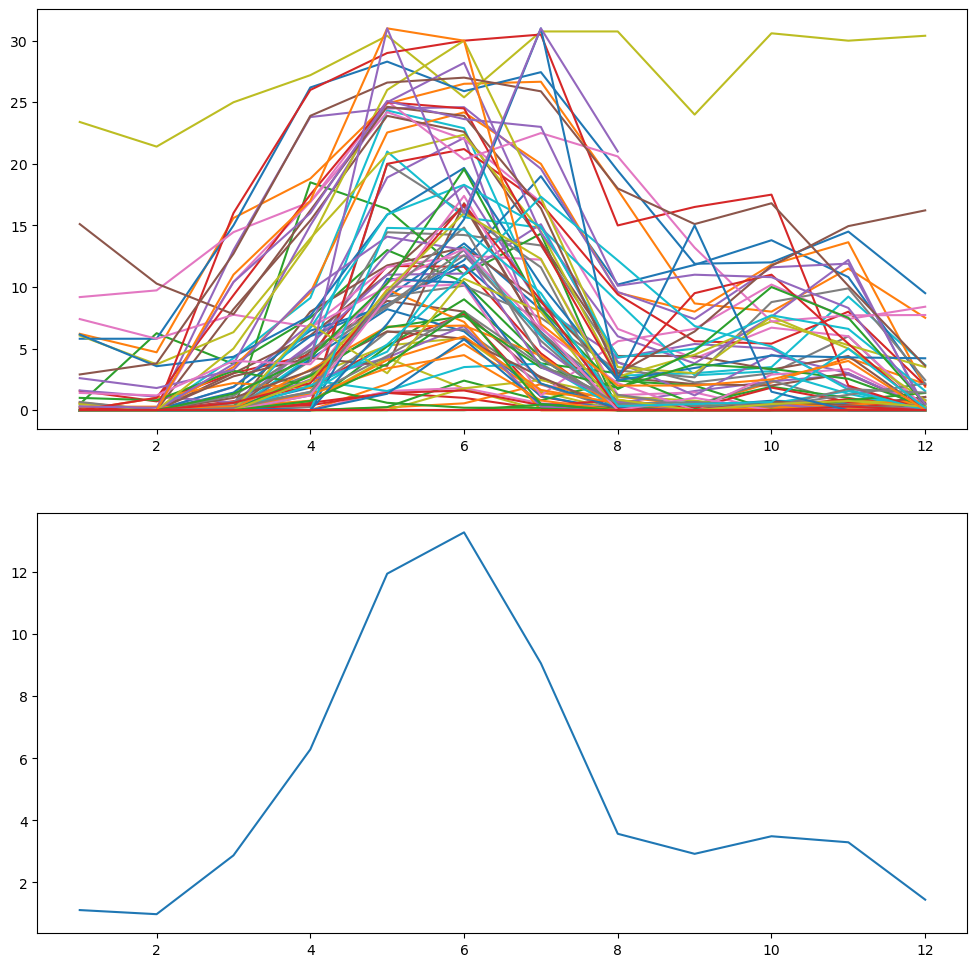

In [ ]:
# checking seasonaliity confounder
def get_mean_month_violation_number(site_uid):
    site = site_uid
    rate = '1MS'
    w = pd.DataFrame(get_data(site).water['nitrate_con'].resample('1D').max())
    w['violation'] = w.nitrate_con >= _VIOLATION_AMOUNT
    w = w.resample(rate).aggregate({'nitrate_con' : 'max', 'violation' : 'sum'}).reset_index()
    w["month"] = w["datetime"].dt.month
    avg = w[['month', 'violation']].groupby("month").agg("mean")
    return avg

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,1, figsize=(12,12))

frames = [get_mean_month_violation_number(s) for s in get_site_ids()]
total = pd.concat(frames).groupby(level="month").sum()
print(total)
for frame in frames:
    axes[0].plot(frame)
axes[1].plot(total/len(get_site_ids())) 
axes[0].set_title("Avg # Violation Days Every Site")
axes[1].set_title("Avg # Days with Violation by Month Across All Sites")
fig.show()